In [1]:
# Install shap if not already installed
# !pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)
import shap
from keras.models import load_model
import pickle

d:\anaconda3\envs\mlops_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
data = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates=['time'], index_col='time')
data = data[:'2025-02']
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [21]:
window = 50
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace=True)

lags = 5
col = []
features = ["sma", "boll", "min", "max", "mom", "vol", "dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace=True)

In [22]:
# Define train_s before using it
train_s = (train - mu) / std

In [23]:
split = int(len(df) * 0.66)
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

mu, std = train.mean(), train.std()

# Load the saved model and params
model = load_model("DNN_model.keras")
with open("params.pkl", "rb") as f:
    params = pickle.load(f)
mu = params["mu"]
std = params["std"]

In [24]:
test_s = (test - mu) / std

# Get predictions
test['proba'] = model.predict(test_s[col])

# Initial position logic (same as DNNStrategy)
test["position"] = np.where(test.proba < 0.47, -1, np.nan)  # short where proba < 0.47
test["position"] = np.where(test.proba > 0.53, 1, test.position)  # long where proba > 0.53
test["hour"] = test.index.hour
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position)  # neutral in non-busy hours
test["position"] = test.position.ffill().fillna(0)  # hold position

1629/1629 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step


In [25]:
# Prepare for XAI Gate using SHAP
background = train_s[col].sample(100, random_state=42).values  # background dataset for SHAP
explainer = shap.DeepExplainer(model, background)

# Function to get XAI decision
def xai_gate(instance, proba, position, threshold=0.005):
    """
    Use SHAP to explain the prediction and decide to allow or deny the model's decision.
    
    Parameters:
    - instance: scaled feature vector for the instance
    - proba: predicted probability
    - position: model's position decision (-1, 0, 1)
    - threshold: minimum absolute SHAP value for top feature to allow
    
    Returns:
    - allow: bool, whether to allow the decision
    - explanation: str, explanation of the decision
    """
    shap_values = explainer.shap_values(instance.reshape(1, -1), check_additivity=False)
    
    # Handle SHAP output format
    if isinstance(shap_values, list):
        if len(shap_values) > 1:
            sv = shap_values[1][0]
        else:
            sv = shap_values[0][0]
    else:
        sv = shap_values[0]
    
    # Get top features
    sv = np.array(sv).flatten()
    abs_sv = np.abs(sv)
    top_indices = np.argsort(abs_sv)[::-1][:3]  # top 3 features
    top_features = [col[int(i)] for i in top_indices]
    top_shap = sv[top_indices]
    
    # Explanation
    explanation = f"Predicted proba: {proba:.3f}, Position: {position}\n"
    explanation += "Top contributing features:\n"
    for feat, shap_val in zip(top_features, top_shap):
        explanation += f"  {feat}: {shap_val:.3f}\n"
    
    # Decision logic
    top_feat = top_features[0]
    # Check if absolute SHAP value matches direction of trade roughly (optional refinement)
    # But for now, just check magnitude and relevance
    if abs_sv[top_indices[0]] > threshold and any(keyword in top_feat for keyword in ['sma', 'boll', 'min', 'max', 'mom', 'vol']):
        allow = True
        explanation += f"Decision: ALLOW (top feature {top_feat} has strong influence and is relevant)"
    else:
        allow = False
        explanation += f"Decision: DENY (insufficient confidence in top feature {top_feat})"
    
    return allow, explanation

d:\anaconda3\envs\mlops_test\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 35))']
  warnings.warn(msg)


In [26]:
# Apply XAI Gate to test data
# Note: This may take time as SHAP computation is expensive
test['xai_allow'] = False
test['xai_explanation'] = ""

# Only evaluate gate when position is not 0 (active trade)
# This saves computation and focuses on actual decisions
active_indices = test[test['position'] != 0].index

for idx in active_indices:
    instance = test_s.loc[idx, col].values
    proba = test.loc[idx, 'proba']
    position = test.loc[idx, 'position']
    allow, explanation = xai_gate(instance, proba, position, threshold=0.005)
    test.loc[idx, 'xai_allow'] = allow
    test.loc[idx, 'xai_explanation'] = explanation

# Now, set position_xai: only take position if xai_allow (for active trades)
# If position was 0, it stays 0
test['position_xai'] = np.where(test['xai_allow'], test['position'], 0)

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


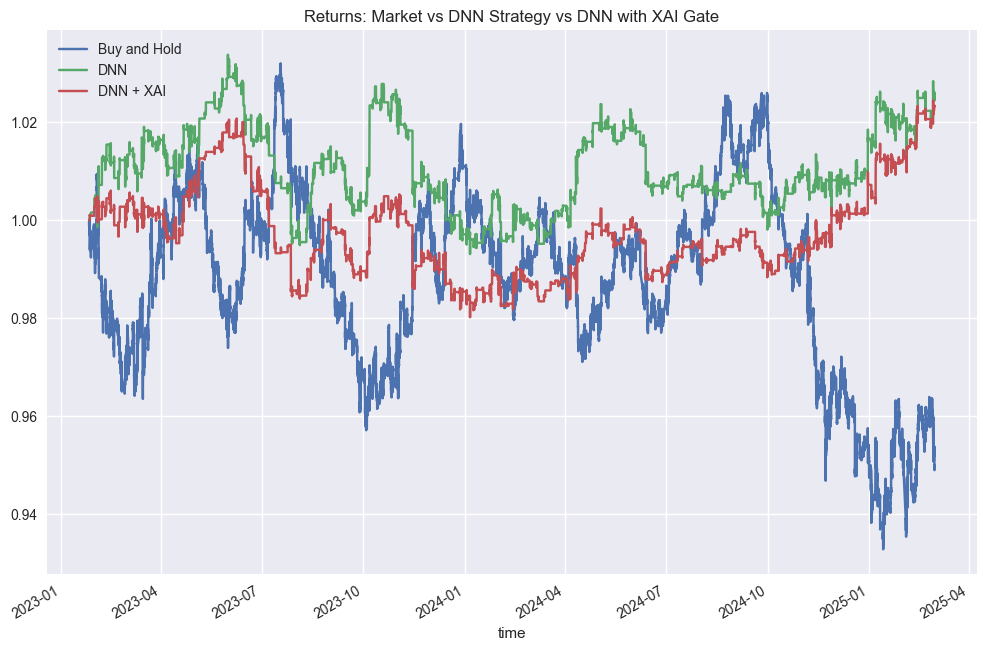

Original DNN Strategy Return: 1.0259101890196083
XAI Filtered Strategy Return: 1.0232351341776103
Allowed decisions: 3280
Denied decisions: 48827


In [27]:
# Compute strategy with XAI gate
test["strategy"] = test["position"] * test["returns"]
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["Buy and Hold"] = test["returns"].cumsum().apply(np.exp)
test["DNN"] = test["strategy"].cumsum().apply(np.exp)
test["DNN + XAI"] = test["strategy_xai"].cumsum().apply(np.exp)

# Plot comparison
test[["Buy and Hold", "DNN", "DNN + XAI"]].plot(figsize=(12, 8))
plt.title("Returns: Market vs DNN Strategy vs DNN with XAI Gate")
plt.show()

# Summary
print("Original DNN Strategy Return:", test["DNN"].iloc[-1])
print("XAI Filtered Strategy Return:", test["DNN + XAI"].iloc[-1])
print("Allowed decisions:", test['xai_allow'].sum())
print("Denied decisions:", (~test['xai_allow']).sum())

In [28]:
# Example explanation for a specific instance
example_idx = test.index[100]  # pick an example
print("Example XAI Explanation:")
print(test.loc[example_idx, 'xai_explanation'])

Example XAI Explanation:

